# 03 — Wrong-Document Popularity Preference

This notebook tests whether wrong retrievals reflect direct preference for popular articles or exposure from the chunked index.

For each wrong retrieval, we compare the target article's popularity to the retrieved article's popularity. We show the same observed wrong-retrieval behavior against two random baselines:

- **Random article baseline**: every article has equal exposure.
- **Random chunk baseline**: articles are weighted by the number of indexed chunks they contribute.

If curves are high above the article baseline but close to the chunk baseline, the apparent popularity preference is mostly an index-exposure effect.

In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.retrieval_gold_document_eval.shared_setup import *

In [6]:
from src.metrics.bias_utils import build_heatmap_pct
from src.metrics.decile_utils import (
    COL_DECILE_CHUNK_WEIGHTED,
    COL_DECILE_UNWEIGHTED,
    load_corpus_distributions,
)

MODE_CONFIGS = [
    ('chunk_weighted', COL_DECILE_CHUNK_WEIGHTED, boundaries_cw),
    ('unweighted', COL_DECILE_UNWEIGHTED, boundaries_uw),
]
DECILES = np.arange(1, 11)
BM25_BASELINE = next((s for s in ALL_STRATEGIES if 'bm25' in s.lower()), ALL_STRATEGIES[0])

def random_decile_distribution(mode: str, unit: str) -> np.ndarray:
    """Return corpus decile probabilities for random articles or random chunks."""
    dists = load_corpus_distributions(corpus_stats, mode)
    if dists is None:
        return np.full(10, 0.1, dtype=float)
    docs_per_decile, chunks_per_decile = dists
    counts = np.asarray(chunks_per_decile if unit == 'chunk' else docs_per_decile, dtype=float)
    total = counts.sum()
    return counts / total if total > 0 else np.full(10, 0.1, dtype=float)

def random_more_popular_baseline(mode: str, unit: str) -> np.ndarray:
    """P(random unit is more popular than a target from decile d)."""
    probs = random_decile_distribution(mode, unit)
    return np.array([probs[d + 1:].sum() + 0.5 * probs[d] for d in range(10)], dtype=float)

def random_heatmap_pct(mode: str, unit: str) -> np.ndarray:
    """Expected row-normalized wrong-doc heatmap under random units."""
    return np.tile(random_decile_distribution(mode, unit) * 100.0, (10, 1))

def headroom_normalized_delta(observed: np.ndarray, baseline: np.ndarray) -> np.ndarray:
    delta = observed - baseline
    denom = np.where(delta >= 0.0, 1.0 - baseline, baseline)
    return np.divide(delta, denom, out=np.full_like(delta, np.nan), where=denom > 0.0)

def wrong_doc_preference_curve(df: pd.DataFrame, decile_col_name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    pref = np.full(10, np.nan, dtype=float)
    ci95 = np.full(10, np.nan, dtype=float)
    n_wrong = np.zeros(10, dtype=int)
    for d in range(10):
        sub = df[df[decile_col_name] == d]
        higher = 0
        total = 0
        for wrong_pops, gold_pop in zip(sub['wrong_docs_popularities'], sub[COL_POPULARITY]):
            if wrong_pops is None or len(wrong_pops) == 0 or pd.isna(gold_pop):
                continue
            for wp in wrong_pops:
                if wp is None or pd.isna(wp):
                    continue
                total += 1
                higher += int(float(wp) > float(gold_pop))
        if total > 0:
            p = higher / total
            pref[d] = p
            ci95[d] = 1.96 * np.sqrt(p * (1.0 - p) / total)
            n_wrong[d] = total
    return pref, ci95, n_wrong

def render_heatmap(ax, matrix: np.ndarray, title: str, *, cmap: str, vmin: float, vmax: float,
                   cbar_label: str, annotate_threshold: float) -> None:
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax, label=cbar_label, pad=0.02, shrink=0.78)
    cbar.ax.tick_params(labelsize=7)
    for i in range(10):
        for j in range(10):
            val = matrix[i, j]
            if np.isfinite(val) and abs(val) >= annotate_threshold:
                label = f'{val:+.0f}' if vmin < 0 else f'{val:.0f}'
                color = 'white' if abs(val) > abs(vmax) * 0.55 else 'black'
                ax.text(j, i, label, ha='center', va='center', fontsize=6, fontweight='bold', color=color)
        ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False,
                                   edgecolor='limegreen', linewidth=1.2))
    ax.set_xticks(range(10)); ax.set_xticklabels(DECILES, fontsize=7)
    ax.set_yticks(range(10)); ax.set_yticklabels(DECILES, fontsize=7)
    ax.set_xlabel('Wrong retrieved decile', fontsize=8, fontweight='bold')
    ax.set_ylabel('Target decile', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=9, fontweight='bold')

## Curve View: Article Baseline vs Chunk Baseline

The same observed wrong-retrieval preference is compared to both baselines. Solid lines use the article baseline; dotted lines use the chunk baseline.

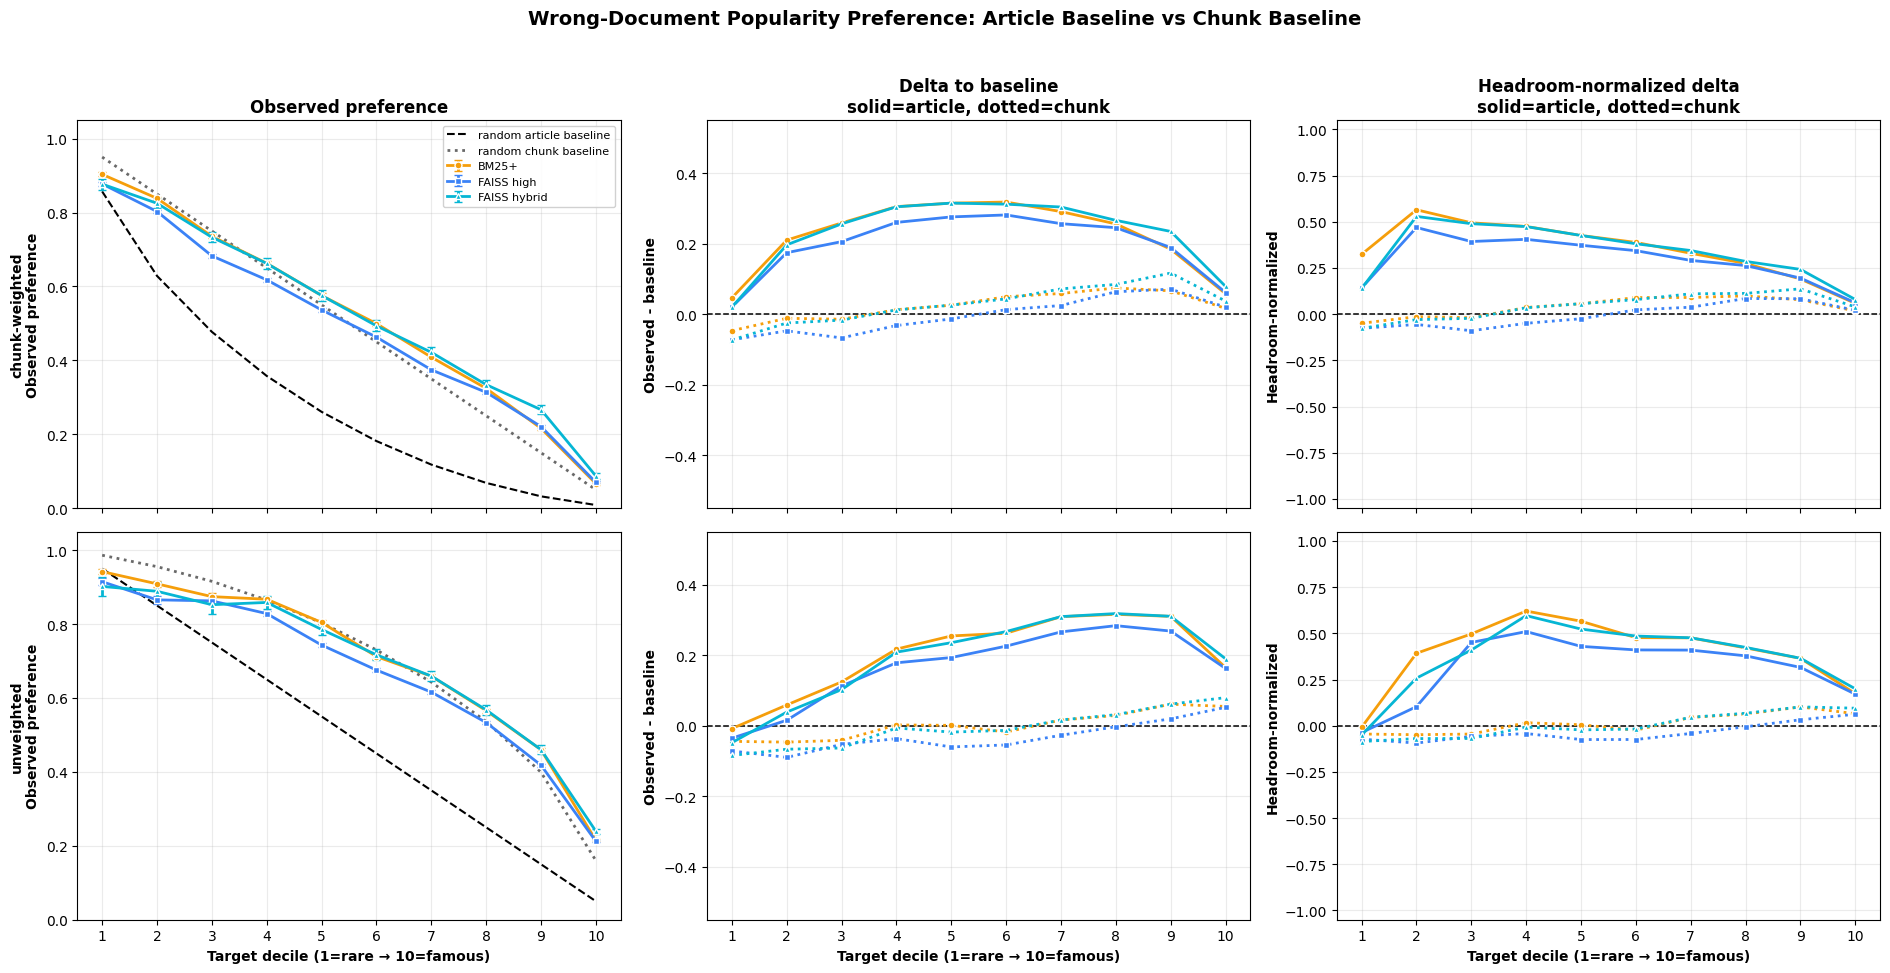

✓ Saved → wrong_doc_preference_article_vs_chunk_baseline.png


,mode,strategy,target_decile,observed_pref,article_baseline,chunk_baseline,delta_article,delta_chunk,headroom_norm_article,headroom_norm_chunk,n_wrong
0,chunk_weighted,retrieved_docs_bm25_plus,1,0.9033,0.8570,0.9500,0.0463,-0.0468,0.3236,-0.0492,13161
1,chunk_weighted,retrieved_docs_bm25_plus,2,0.8384,0.6285,0.8501,0.2099,-0.0117,0.5649,-0.0138,21807
2,chunk_weighted,retrieved_docs_bm25_plus,3,0.7357,0.4771,0.7500,0.2586,-0.0144,0.4945,-0.0192,28467
3,chunk_weighted,retrieved_docs_bm25_plus,4,0.6627,0.3578,0.6500,0.3049,0.0126,0.4747,0.0361,30144
4,chunk_weighted,retrieved_docs_bm25_plus,5,0.5754,0.2607,0.5500,0.3147,0.0254,0.4257,0.0564,30284
5,chunk_weighted,retrieved_docs_bm25_plus,6,0.4994,0.1816,0.4500,0.3178,0.0494,0.3883,0.0898,29960
6,chunk_weighted,retrieved_docs_bm25_plus,7,0.4086,0.1180,0.3500,0.2907,0.0586,0.3295,0.0902,30279
7,chunk_weighted,retrieved_docs_bm25_plus,8,0.3242,0.0684,0.2500,0.2558,0.0742,0.2745,0.0989,30633
8,chunk_weighted,retrieved_docs_bm25_plus,9,0.2161,0.0320,0.1500,0.1841,0.0661,0.1902,0.0778,30386
9,chunk_weighted,retrieved_docs_bm25_plus,10,0.0664,0.0085,0.0500,0.0579,0.0164,0.0584,0.0173,30286


In [7]:
fig, axes = plt.subplots(len(MODE_CONFIGS), 3, figsize=(19, 9.5), sharex=True)
preference_rows = []

for row_idx, (mode, dec_col_mode, _boundaries_mode) in enumerate(MODE_CONFIGS):
    article_baseline = random_more_popular_baseline(mode, 'doc')
    chunk_baseline = random_more_popular_baseline(mode, 'chunk')

    axes[row_idx, 0].plot(DECILES, article_baseline, color='black', linestyle='--',
                          linewidth=1.5, label='random article baseline')
    axes[row_idx, 0].plot(DECILES, chunk_baseline, color='dimgray', linestyle=':',
                          linewidth=2.0, label='random chunk baseline')
    axes[row_idx, 1].axhline(0.0, color='black', linestyle='--', linewidth=1.1)
    axes[row_idx, 2].axhline(0.0, color='black', linestyle='--', linewidth=1.1)

    for strategy in ALL_STRATEGIES:
        df = results_by_strategy[strategy]
        if dec_col_mode not in df.columns:
            continue
        observed, ci95, n_wrong = wrong_doc_preference_curve(df, dec_col_mode)
        valid = np.isfinite(observed)
        if not valid.any():
            continue

        delta_article = observed - article_baseline
        delta_chunk = observed - chunk_baseline
        norm_article = headroom_normalized_delta(observed, article_baseline)
        norm_chunk = headroom_normalized_delta(observed, chunk_baseline)
        color = strategy_colors.get(strategy)
        marker = markers.get(strategy, 'o')
        label = strategy_label(strategy)

        axes[row_idx, 0].errorbar(DECILES[valid], observed[valid], yerr=ci95[valid],
                                  color=color, marker=marker, markersize=5, linewidth=2.0,
                                  capsize=3, markeredgecolor='white', label=label)
        axes[row_idx, 1].plot(DECILES[valid], delta_article[valid], color=color, marker=marker,
                              linestyle='-', linewidth=2.0, markersize=5, markeredgecolor='white',
                              label=f'{label} vs article')
        axes[row_idx, 1].plot(DECILES[valid], delta_chunk[valid], color=color, marker=marker,
                              linestyle=':', linewidth=2.0, markersize=5, markeredgecolor='white',
                              label=f'{label} vs chunk')
        axes[row_idx, 2].plot(DECILES[valid], norm_article[valid], color=color, marker=marker,
                              linestyle='-', linewidth=2.0, markersize=5, markeredgecolor='white')
        axes[row_idx, 2].plot(DECILES[valid], norm_chunk[valid], color=color, marker=marker,
                              linestyle=':', linewidth=2.0, markersize=5, markeredgecolor='white')

        for d in range(10):
            preference_rows.append({
                'mode': mode,
                'strategy': strategy,
                'target_decile': d + 1,
                'observed_pref': observed[d],
                'article_baseline': article_baseline[d],
                'chunk_baseline': chunk_baseline[d],
                'delta_article': delta_article[d],
                'delta_chunk': delta_chunk[d],
                'headroom_norm_article': norm_article[d],
                'headroom_norm_chunk': norm_chunk[d],
                'n_wrong': int(n_wrong[d]),
            })

    axes[row_idx, 0].set_ylabel(mode.replace('_', '-') + '\nObserved preference', fontsize=10, fontweight='bold')
    axes[row_idx, 1].set_ylabel('Observed - baseline', fontsize=10, fontweight='bold')
    axes[row_idx, 2].set_ylabel('Headroom-normalized', fontsize=10, fontweight='bold')
    axes[row_idx, 0].set_ylim(0.0, 1.05)
    axes[row_idx, 1].set_ylim(-0.55, 0.55)
    axes[row_idx, 2].set_ylim(-1.05, 1.05)
    for ax in axes[row_idx]:
        ax.set_xticks(DECILES)
        ax.grid(alpha=0.25)

axes[0, 0].set_title('Observed preference', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Delta to baseline\nsolid=article, dotted=chunk', fontsize=12, fontweight='bold')
axes[0, 2].set_title('Headroom-normalized delta\nsolid=article, dotted=chunk', fontsize=12, fontweight='bold')
for ax in axes[-1]:
    ax.set_xlabel('Target decile (1=rare → 10=famous)', fontsize=10, fontweight='bold')
axes[0, 0].legend(fontsize=8, framealpha=0.9, loc='best')
fig.suptitle('Wrong-Document Popularity Preference: Article Baseline vs Chunk Baseline',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out = IMAGES_DIR / 'wrong_doc_preference_article_vs_chunk_baseline.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

preference_df = pd.DataFrame(preference_rows)
display(preference_df.round(4))

## Final Figure: Observed Preference Under Chunk-Weighted Deciles

This is the compact figure for the paper: observed wrong-document popularity preference under chunk-weighted deciles, with both the random article and random chunk baselines shown. Vertical bars are 95% normal binomial confidence intervals over wrong retrieved chunks; they quantify sampling uncertainty, not direct scorer-level preference.

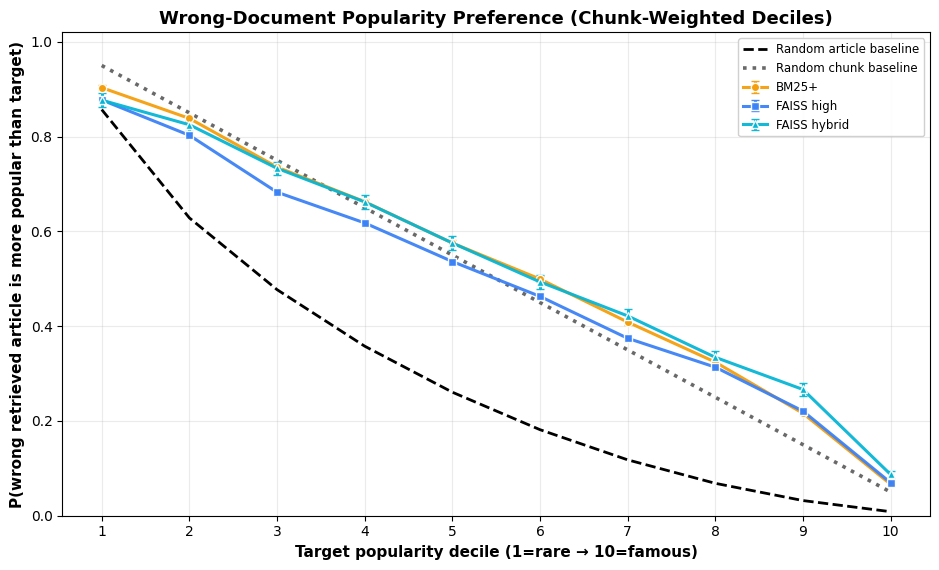

✓ Saved → wrong_doc_observed_preference_chunk_weighted.png


In [8]:
mode = 'chunk_weighted'
dec_col_mode = COL_DECILE_CHUNK_WEIGHTED
article_baseline = random_more_popular_baseline(mode, 'doc')
chunk_baseline = random_more_popular_baseline(mode, 'chunk')

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.plot(DECILES, article_baseline, color='black', linestyle='--', linewidth=2.0,
        label='Random article baseline')
ax.plot(DECILES, chunk_baseline, color='dimgray', linestyle=':', linewidth=2.6,
        label='Random chunk baseline')

for strategy in ALL_STRATEGIES:
    df = results_by_strategy[strategy]
    if dec_col_mode not in df.columns:
        continue
    observed, ci95, _n_wrong = wrong_doc_preference_curve(df, dec_col_mode)
    valid = np.isfinite(observed)
    if not valid.any():
        continue
    ax.errorbar(
        DECILES[valid], observed[valid], yerr=ci95[valid],
        color=strategy_colors.get(strategy), marker=markers.get(strategy, 'o'),
        linewidth=2.2, markersize=6, capsize=3, markeredgecolor='white',
        label=strategy_label(strategy), alpha=0.95,
    )

ax.set_title('Wrong-Document Popularity Preference (Chunk-Weighted Deciles)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Target popularity decile (1=rare → 10=famous)', fontsize=11, fontweight='bold')
ax.set_ylabel('P(wrong retrieved article is more popular than target)',
              fontsize=11, fontweight='bold')
ax.set_xticks(DECILES)
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8.5, framealpha=0.92, loc='best')
plt.tight_layout()
out = IMAGES_DIR / 'wrong_doc_observed_preference_chunk_weighted.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## Heatmap View: Observed, Article Baseline, Chunk Baseline, BM25 Baseline

Rows are target deciles and columns are wrong-retrieved article deciles. The article-baseline delta shows apparent popularity preference relative to equal article exposure. The chunk-baseline delta shows what remains after accounting for chunk exposure in the index.

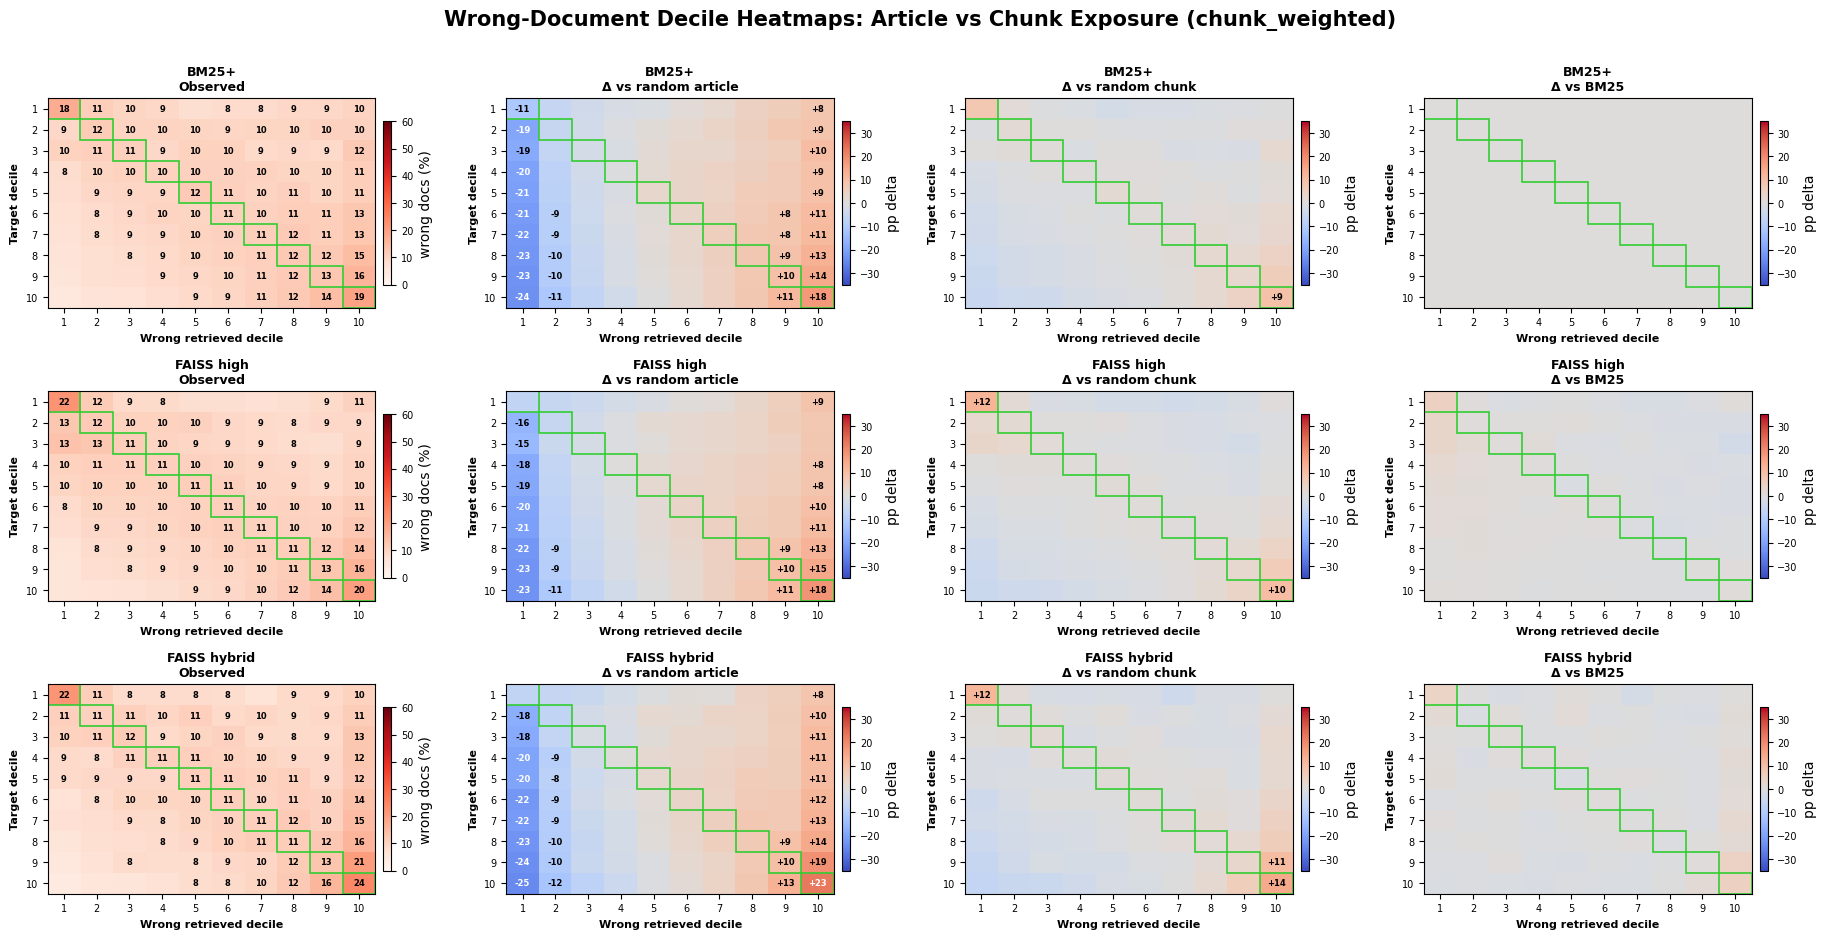

✓ Saved → wrong_doc_heatmaps_article_vs_chunk_baseline_chunk_weighted.png


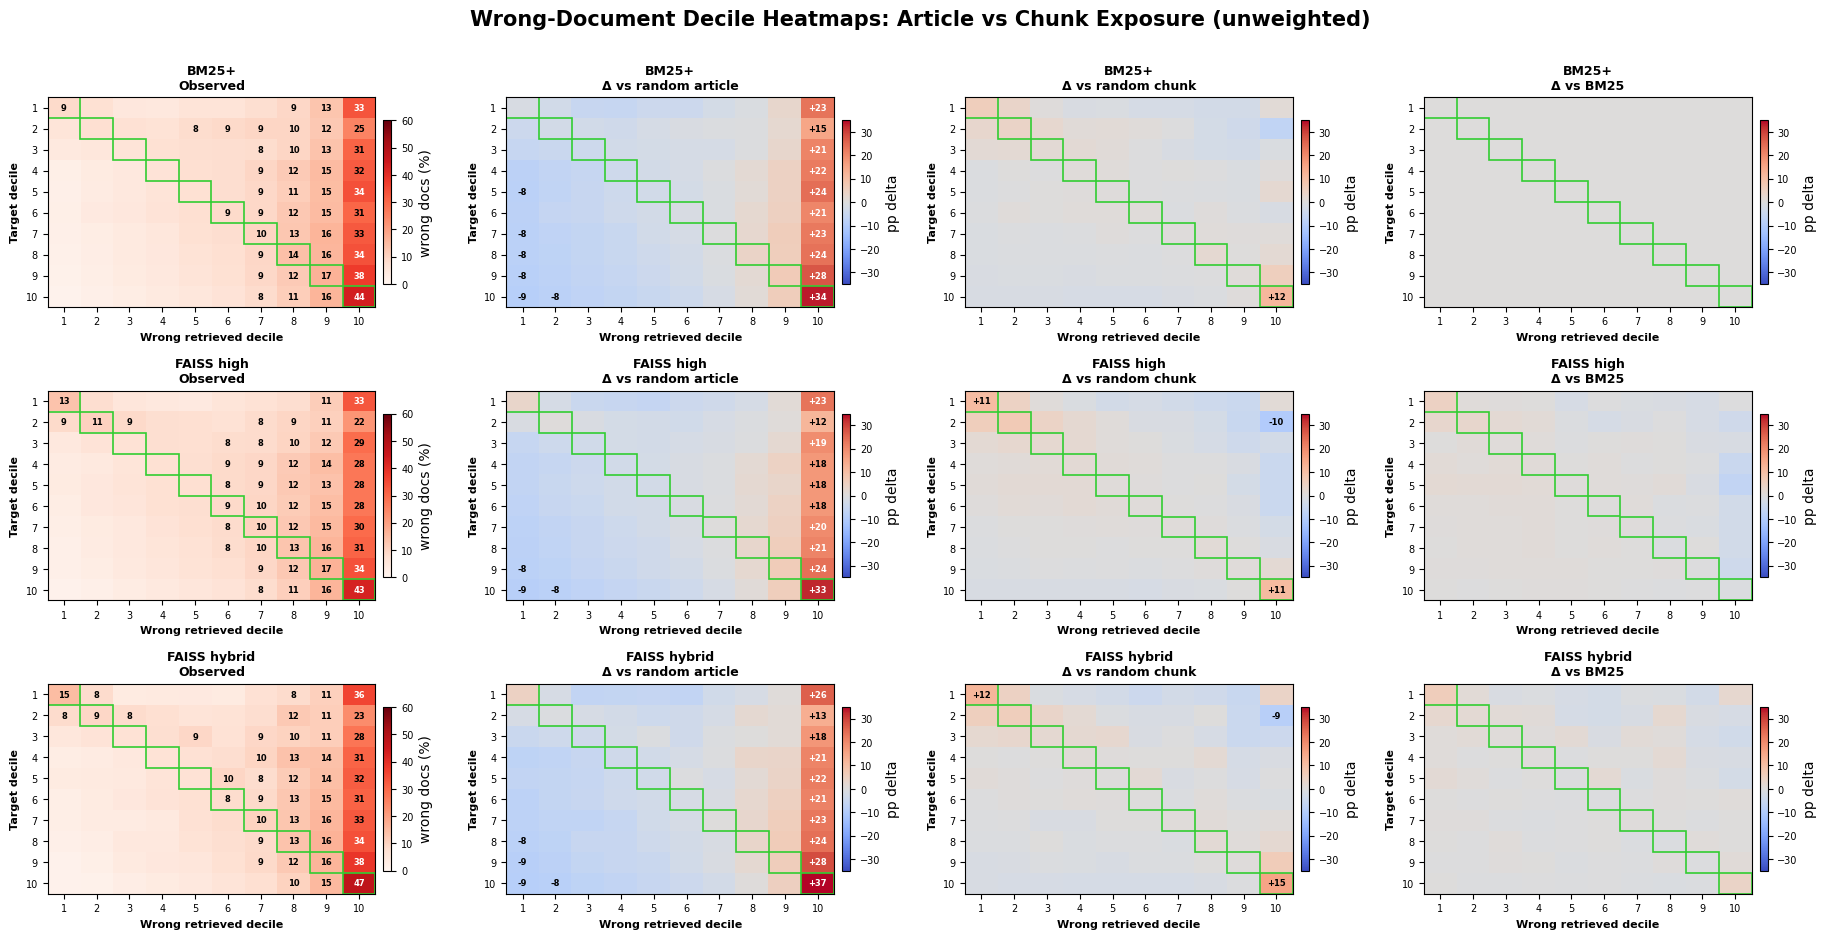

✓ Saved → wrong_doc_heatmaps_article_vs_chunk_baseline_unweighted.png


In [9]:
heatmaps: dict[tuple[str, str], np.ndarray] = {}
for mode, dec_col_mode, boundaries_mode in MODE_CONFIGS:
    for strategy in ALL_STRATEGIES:
        df = results_by_strategy[strategy]
        if dec_col_mode in df.columns:
            heatmaps[(mode, strategy)] = build_heatmap_pct(df, dec_col_mode, boundaries_mode)

for mode, _dec_col_mode, _boundaries_mode in MODE_CONFIGS:
    article_random_hm = random_heatmap_pct(mode, 'doc')
    chunk_random_hm = random_heatmap_pct(mode, 'chunk')
    bm25_hm = heatmaps.get((mode, BM25_BASELINE))
    fig, axes = plt.subplots(len(ALL_STRATEGIES), 4, figsize=(18.5, 3.1 * len(ALL_STRATEGIES)), squeeze=False)

    for row_idx, strategy in enumerate(ALL_STRATEGIES):
        hm = heatmaps.get((mode, strategy))
        if hm is None:
            for ax in axes[row_idx]:
                ax.axis('off')
            continue
        render_heatmap(axes[row_idx, 0], hm, f'{strategy_label(strategy)}\nObserved',
                       cmap='Reds', vmin=0.0, vmax=60.0, cbar_label='wrong docs (%)', annotate_threshold=8.0)
        render_heatmap(axes[row_idx, 1], hm - article_random_hm, f'{strategy_label(strategy)}\nΔ vs random article',
                       cmap='coolwarm', vmin=-35.0, vmax=35.0, cbar_label='pp delta', annotate_threshold=8.0)
        render_heatmap(axes[row_idx, 2], hm - chunk_random_hm, f'{strategy_label(strategy)}\nΔ vs random chunk',
                       cmap='coolwarm', vmin=-35.0, vmax=35.0, cbar_label='pp delta', annotate_threshold=8.0)
        if bm25_hm is None:
            axes[row_idx, 3].axis('off')
        else:
            render_heatmap(axes[row_idx, 3], hm - bm25_hm, f'{strategy_label(strategy)}\nΔ vs BM25',
                           cmap='coolwarm', vmin=-35.0, vmax=35.0, cbar_label='pp delta', annotate_threshold=8.0)

    fig.suptitle(f'Wrong-Document Decile Heatmaps: Article vs Chunk Exposure ({mode})',
                 fontsize=15, fontweight='bold', y=1.005)
    plt.tight_layout()
    out = IMAGES_DIR / f'wrong_doc_heatmaps_article_vs_chunk_baseline_{mode}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved → {out.name}')